In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [7]:
# Load dataset
df = pd.read_csv("C:/Users/keerthana/Downloads/supermarket_sales.csv")

# Display first rows
df.head()

,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,18:54,Credit card,8.4
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,18:44,Credit card,4.3
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,16:16,Cash,9.6
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,11:35,Cash,4.5
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,8:56,Credit card,5.8


In [9]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset info
print("\nDataset Info:")
df.info()

Dataset Shape: (2000, 14)

Columns:
Index(['Invoice_ID', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax', 'Total', 'Date',
       'Time', 'Payment', 'Rating'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice_ID     2000 non-null   object 
 1   Branch         2000 non-null   object 
 2   City           2000 non-null   object 
 3   Customer_Type  2000 non-null   object 
 4   Gender         2000 non-null   object 
 5   Product_Line   2000 non-null   object 
 6   Unit_Price     2000 non-null   float64
 7   Quantity       2000 non-null   int64  
 8   Tax            2000 non-null   float64
 9   Total          2000 non-null   float64
 10  Date           2000 non-null   object 
 11  Time           2000 non-null   object 
 12  Payment        2000 non

In [11]:
df.isnull().sum()

Invoice_ID       0
Branch           0
City             0
Customer_Type    0
Gender           0
Product_Line     0
Unit_Price       0
Quantity         0
Tax              0
Total            0
Date             0
Time             0
Payment          0
Rating           0
dtype: int64

In [13]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Convert Time column
df['Time'] = pd.to_datetime(df['Time'])

# Extract useful features
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day_name()
df['Hour'] = df['Time'].dt.hour

df.head()

C:\Users\keerthana\AppData\Local\Temp\ipykernel_18132\3832701593.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


,Invoice_ID,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax,Total,Date,Time,Payment,Rating,Month,Day,Hour
0,INV000001,B,Mandalay,Member,Male,Food & Beverages,69.36,3,7.28,119.58,2023-08-08,2026-03-09 18:54:00,Credit card,8.4,8,Tuesday,18
1,INV000002,C,Mandalay,Member,Female,Food & Beverages,35.25,1,6.62,137.13,2023-02-09,2026-03-09 18:44:00,Credit card,4.3,2,Thursday,18
2,INV000003,C,Naypyitaw,Normal,Female,Fashion Accessories,57.56,8,4.66,490.48,2023-08-24,2026-03-09 16:16:00,Cash,9.6,8,Thursday,16
3,INV000004,B,Naypyitaw,Member,Female,Food & Beverages,16.60,5,8.57,142.54,2023-02-09,2026-03-09 11:35:00,Cash,4.5,2,Thursday,11
4,INV000005,C,Yangon,Normal,Female,Food & Beverages,49.07,1,3.70,24.43,2023-07-04,2026-03-09 08:56:00,Credit card,5.8,7,Tuesday,8


In [15]:
total_sales = df['Total'].sum()
avg_transaction = df['Total'].mean()
total_items = df['Quantity'].sum()

print("Total Sales:", total_sales)
print("Average Transaction Value:", avg_transaction)
print("Total Items Sold:", total_items)

Total Sales: 519280.69
Average Transaction Value: 259.640345
Total Items Sold: 10066


In [17]:
product_sales = df.groupby('Product_Line')['Quantity'].sum().sort_values(ascending=False)

print(product_sales)

Product_Line
Health & Beauty           1866
Sports & Travel           1737
Electronic Accessories    1691
Home & Lifestyle          1654
Food & Beverages          1618
Fashion Accessories       1500
Name: Quantity, dtype: int64


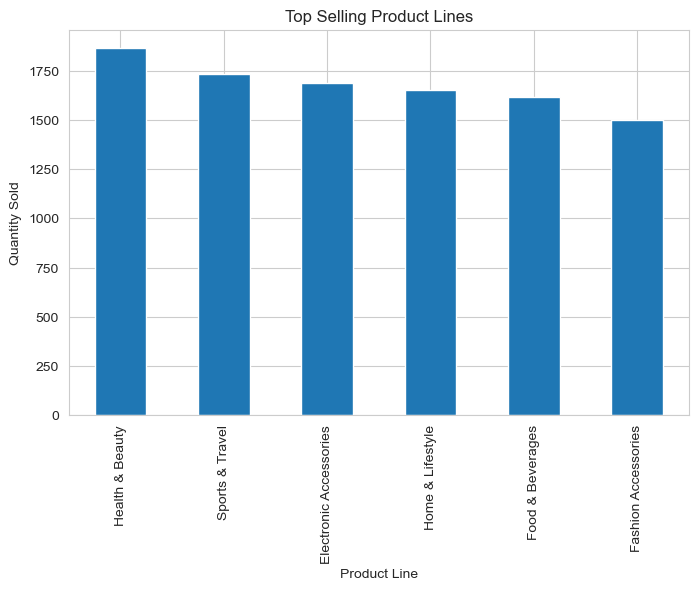

In [19]:
product_sales.plot(kind='bar')

plt.title("Top Selling Product Lines")
plt.xlabel("Product Line")
plt.ylabel("Quantity Sold")

plt.show()

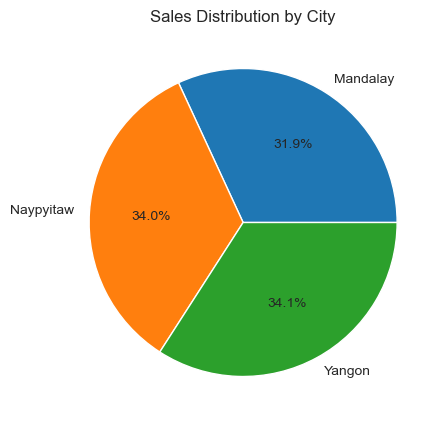

In [21]:
city_sales = df.groupby('City')['Total'].sum()

city_sales.plot(kind='pie', autopct='%1.1f%%')

plt.title("Sales Distribution by City")
plt.ylabel("")

plt.show()

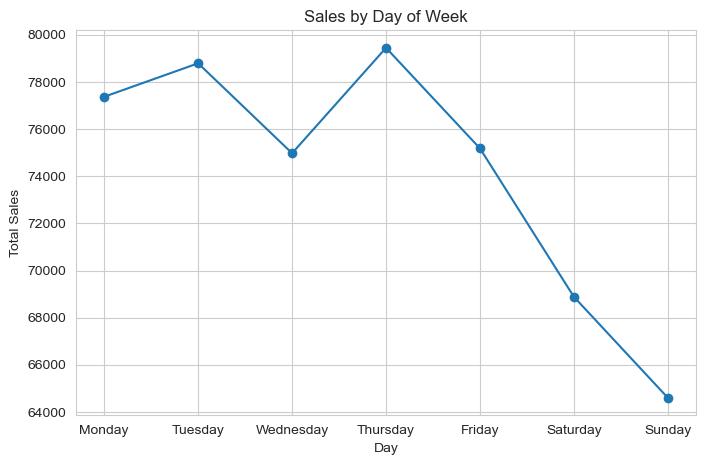

In [23]:
day_sales = df.groupby('Day')['Total'].sum()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = day_sales.reindex(order)

day_sales.plot(marker='o')

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Sales")

plt.show()

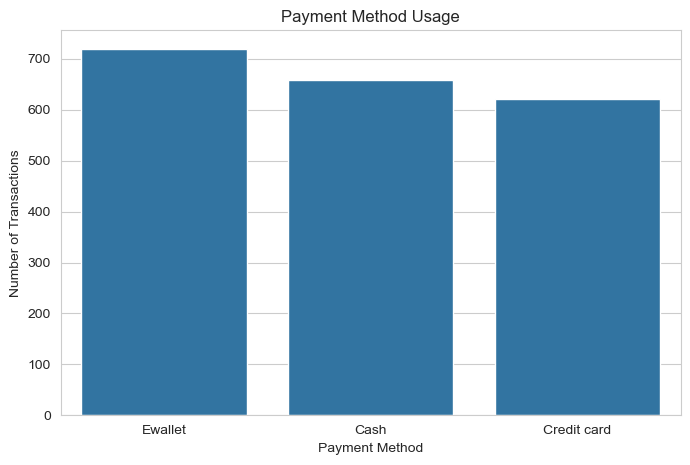

In [25]:
payment_counts = df['Payment'].value_counts()

sns.barplot(x=payment_counts.index, y=payment_counts.values)

plt.title("Payment Method Usage")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.show()

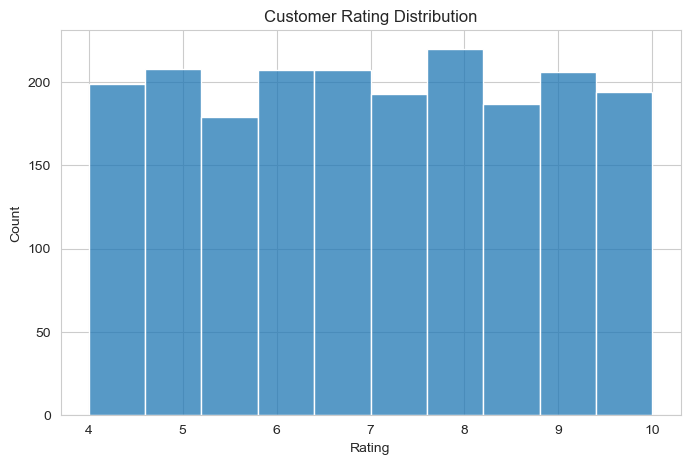

In [27]:
sns.histplot(df['Rating'], bins=10)

plt.title("Customer Rating Distribution")
plt.xlabel("Rating")

plt.show()

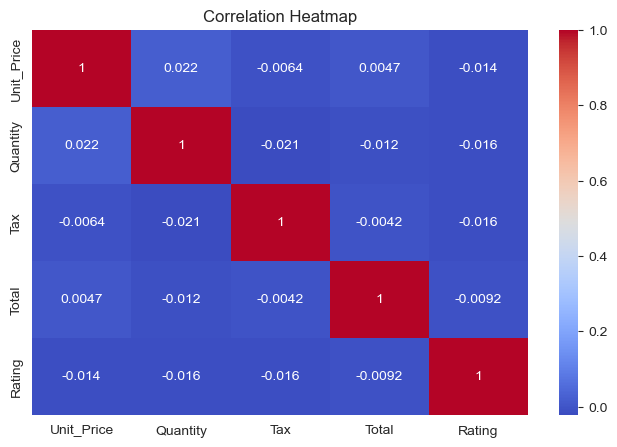

In [29]:
numeric_cols = df[['Unit_Price','Quantity','Tax','Total','Rating']]

corr_matrix = numeric_cols.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

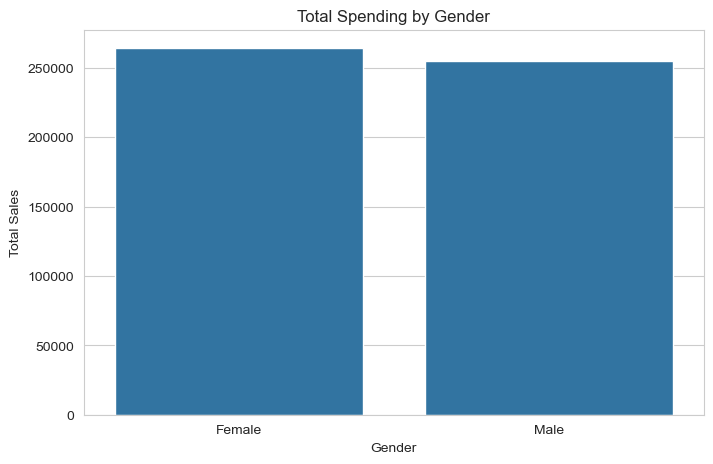

In [31]:
gender_sales = df.groupby('Gender')['Total'].sum()

sns.barplot(x=gender_sales.index, y=gender_sales.values)

plt.title("Total Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.show()

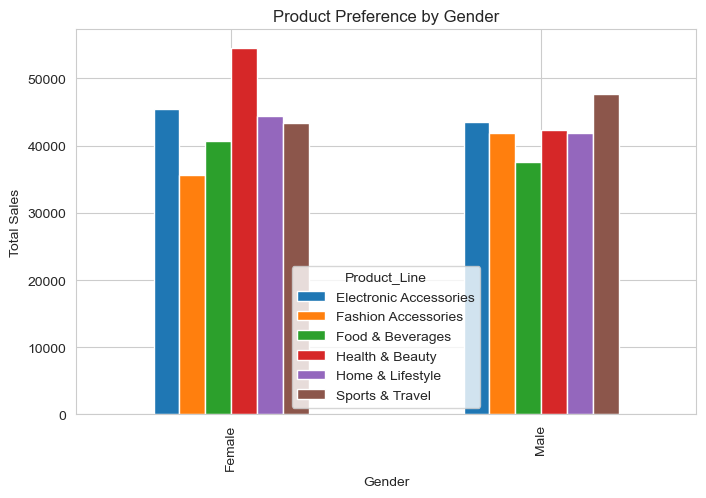

In [33]:
gender_product = df.groupby(['Gender','Product_Line'])['Total'].sum().unstack()

gender_product.plot(kind='bar')

plt.title("Product Preference by Gender")
plt.ylabel("Total Sales")

plt.show()

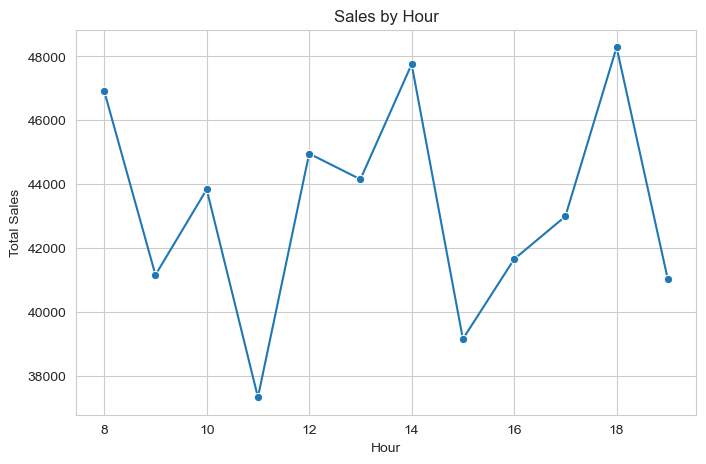

In [35]:
hourly_sales = df.groupby('Hour')['Total'].sum()

sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o')

plt.title("Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Total Sales")

plt.show()

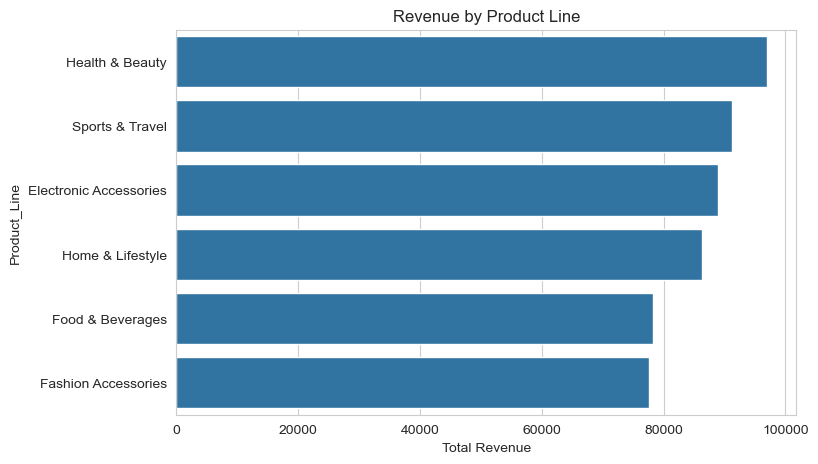

In [37]:
product_revenue = df.groupby('Product_Line')['Total'].sum().sort_values(ascending=False)

sns.barplot(x=product_revenue.values, y=product_revenue.index)

plt.title("Revenue by Product Line")
plt.xlabel("Total Revenue")

plt.show()

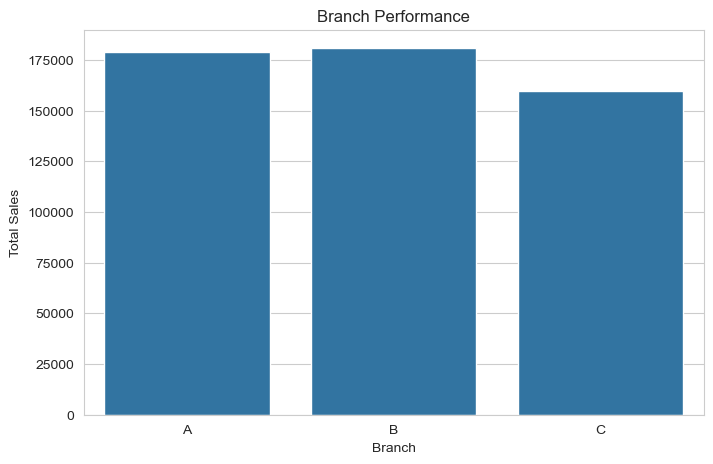

In [39]:
branch_sales = df.groupby('Branch')['Total'].sum()

sns.barplot(x=branch_sales.index, y=branch_sales.values)

plt.title("Branch Performance")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.show()

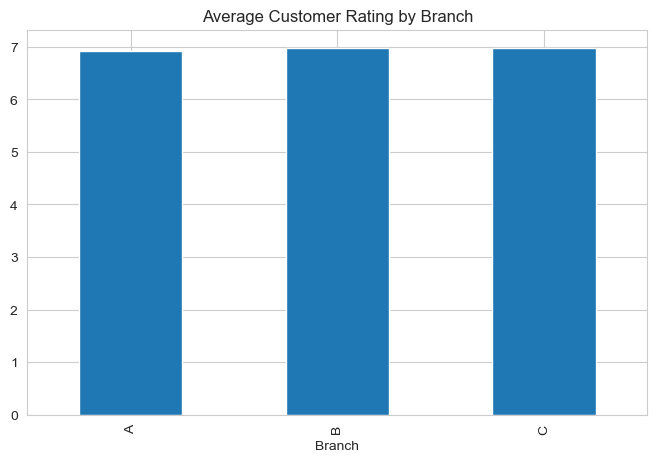

In [41]:
branch_rating = df.groupby('Branch')['Rating'].mean()

branch_rating.plot(kind='bar')

plt.title("Average Customer Rating by Branch")

plt.show()

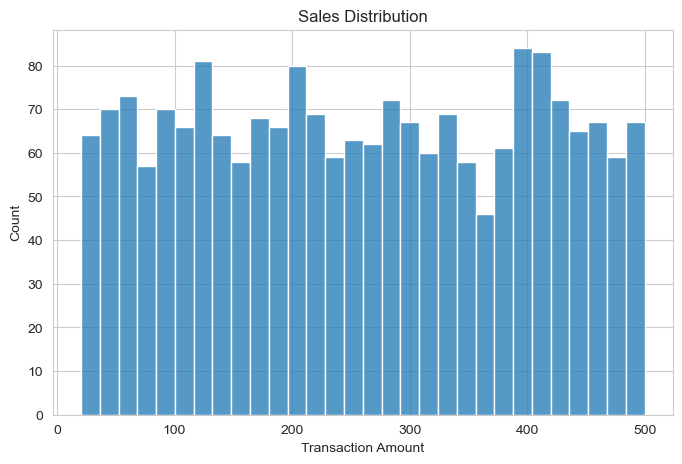

In [45]:
sns.histplot(df['Total'], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Transaction Amount")

plt.show()

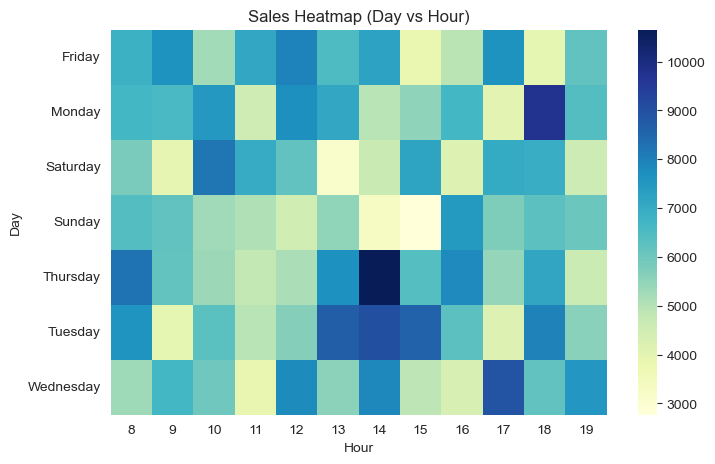

In [47]:
sales_pivot = df.pivot_table(values='Total',
                             index='Day',
                             columns='Hour',
                             aggfunc='sum')

sns.heatmap(sales_pivot, cmap='YlGnBu')

plt.title("Sales Heatmap (Day vs Hour)")

plt.show()